<a href="https://colab.research.google.com/github/hansikawork-432/CAR-PRICE-PREDICTION-WITH-ML/blob/main/Car%20price%20prediction%20using%20machine%20learning_BY_Hansika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
mpl.style.use('ggplot')

In [6]:
car_data=pd.read_csv('car.csv')

In [132]:
car_data.head()

,Unnamed: 0,Name,Label,Location,Price,Kms_driven,Fuel_type,Owner,Year,Company
0,0,Ford Figo Duratec,PLATINUM,Bangalore,380000,35056,Petrol,NaN,2015,Ford
1,1,Maruti Suzuki Wagon,PLATINUM,Bangalore,465000,44000,Petrol,NaN,2016,Maruti
2,2,Hyundai Creta 1.6,PLATINUM,Bangalore,1350000,42917,Petrol,NaN,2018,Hyundai
3,3,Hyundai Venue -,PLATINUM,Chennai,1019699,16112,Petrol,2nd Owner,2019,Hyundai
4,4,Honda Jazz -,PLATINUM,Pune,713499,30988,Petrol,2nd Owner,2017,Honda


In [10]:
car_data.shape

(1032, 10)

In [133]:
car_data.info

<bound method DataFrame.info of       Unnamed: 0                  Name     Label    Location    Price  \
0              0     Ford Figo Duratec  PLATINUM   Bangalore   380000   
1              1   Maruti Suzuki Wagon  PLATINUM   Bangalore   465000   
2              2     Hyundai Creta 1.6  PLATINUM   Bangalore  1350000   
3              3       Hyundai Venue -  PLATINUM     Chennai  1019699   
4              4          Honda Jazz -  PLATINUM        Pune   713499   
...          ...                   ...       ...         ...      ...   
1021        1027     Hyundai i10 Magna      GOLD   Bangalore   229000   
1022        1028    Maruti Suzuki Alto      GOLD   Bangalore   275000   
1023        1029  Jeep Compass Limited      GOLD  Mahasamund  1750000   
1024        1030  Jeep Compass Limited      GOLD    Bilaspur  1750000   
1025        1031  Jeep Compass Limited      GOLD   Jagdalpur  1750000   

      Kms_driven Fuel_type       Owner  Year  Company  
0          35056    Petrol         NaN  2015     Ford  
1          44000    Petrol         NaN  2016   Maruti  
2          42917    Petrol         NaN  2018  Hyundai  
3          16112   Petrol    2nd Owner  2019  Hyundai  
4          30988   Petrol    2nd Owner  2017    Honda  
...          ...       ...         ...   ...      ...  
1021       65000   Petrol    1st Owner  2014  Hyundai  
1022       60000    Petrol         NaN  2014   Maruti  
1023       31000   Diesel    1st Owner  2017     Jeep  
1024       31000   Diesel    1st Owner  2017     Jeep  
1025       31000   Diesel    1st Owner  2017     Jeep  

[1026 rows x 10 columns]>

In [15]:
#backup copy
backup_copy=car_data.copy()


Quality of the data:

1. Names are not consistent.

2. Names have company names.

3. Some names are spam.

4. Many of the company names are not specific.

5. Year has many non-year values.

6. Year datatype should be changed to int.

7. Price has commas in its prices and is in object.

8. Kms_driven has object values with kms at last.

9. It has nan values and two rows have 'Petrol' in them.

10. fuel_type has nan values.

Data Cleaning

In [22]:
#year has non-year values
car_data = car_data[car_data['Year'].astype(str).str.isnumeric()]
car_data['Year'] = car_data['Year'].astype(int)

In [30]:
#  'Ask For Price' rows
car_data = car_data[car_data['Price'] != 'Ask For Price']


car_data['Price'] = car_data['Price'].astype(str).str.replace(',', '').str.replace('₹', '').astype(int)

In [41]:

car_data['Kms_driven'] = car_data['Kms_driven'].astype(str).str.replace(',', '').str.replace(' kms', '').astype(int)

In [45]:
car_data = car_data[~car_data['Fuel_type'].isna()]

In [47]:
car_data.shape

(1026, 10)

In [51]:
car_data['Name'] = car_data['Name'].str.split().str.slice(start=0, stop=3).str.join(' ')

In [53]:
car_data=car_data.reset_index(drop=True)


Cleaned Data

In [134]:
car_data

,Unnamed: 0,Name,Label,Location,Price,Kms_driven,Fuel_type,Owner,Year,Company
0,0,Ford Figo Duratec,PLATINUM,Bangalore,380000,35056,Petrol,NaN,2015,Ford
1,1,Maruti Suzuki Wagon,PLATINUM,Bangalore,465000,44000,Petrol,NaN,2016,Maruti
2,2,Hyundai Creta 1.6,PLATINUM,Bangalore,1350000,42917,Petrol,NaN,2018,Hyundai
3,3,Hyundai Venue -,PLATINUM,Chennai,1019699,16112,Petrol,2nd Owner,2019,Hyundai
4,4,Honda Jazz -,PLATINUM,Pune,713499,30988,Petrol,2nd Owner,2017,Honda
...,...,...,...,...,...,...,...,...,...,...
1021,1027,Hyundai i10 Magna,GOLD,Bangalore,229000,65000,Petrol,1st Owner,2014,Hyundai
1022,1028,Maruti Suzuki Alto,GOLD,Bangalore,275000,60000,Petrol,NaN,2014,Maruti
1023,1029,Jeep Compass Limited,GOLD,Mahasamund,1750000,31000,Diesel,1st Owner,2017,Jeep
1024,1030,Jeep Compass Limited,GOLD,Bilaspur,1750000,31000,Diesel,1st Owner,2017,Jeep


In [135]:
car_data.to_csv

<bound method NDFrame.to_csv of       Unnamed: 0                  Name     Label    Location    Price  \
0              0     Ford Figo Duratec  PLATINUM   Bangalore   380000   
1              1   Maruti Suzuki Wagon  PLATINUM   Bangalore   465000   
2              2     Hyundai Creta 1.6  PLATINUM   Bangalore  1350000   
3              3       Hyundai Venue -  PLATINUM     Chennai  1019699   
4              4          Honda Jazz -  PLATINUM        Pune   713499   
...          ...                   ...       ...         ...      ...   
1021        1027     Hyundai i10 Magna      GOLD   Bangalore   229000   
1022        1028    Maruti Suzuki Alto      GOLD   Bangalore   275000   
1023        1029  Jeep Compass Limited      GOLD  Mahasamund  1750000   
1024        1030  Jeep Compass Limited      GOLD    Bilaspur  1750000   
1025        1031  Jeep Compass Limited      GOLD   Jagdalpur  1750000   

      Kms_driven Fuel_type       Owner  Year  Company  
0          35056    Petrol         NaN  2015     Ford  
1          44000    Petrol         NaN  2016   Maruti  
2          42917    Petrol         NaN  2018  Hyundai  
3          16112   Petrol    2nd Owner  2019  Hyundai  
4          30988   Petrol    2nd Owner  2017    Honda  
...          ...       ...         ...   ...      ...  
1021       65000   Petrol    1st Owner  2014  Hyundai  
1022       60000    Petrol         NaN  2014   Maruti  
1023       31000   Diesel    1st Owner  2017     Jeep  
1024       31000   Diesel    1st Owner  2017     Jeep  
1025       31000   Diesel    1st Owner  2017     Jeep  

[1026 rows x 10 columns]>

In [136]:
car_data.info

<bound method DataFrame.info of       Unnamed: 0                  Name     Label    Location    Price  \
0              0     Ford Figo Duratec  PLATINUM   Bangalore   380000   
1              1   Maruti Suzuki Wagon  PLATINUM   Bangalore   465000   
2              2     Hyundai Creta 1.6  PLATINUM   Bangalore  1350000   
3              3       Hyundai Venue -  PLATINUM     Chennai  1019699   
4              4          Honda Jazz -  PLATINUM        Pune   713499   
...          ...                   ...       ...         ...      ...   
1021        1027     Hyundai i10 Magna      GOLD   Bangalore   229000   
1022        1028    Maruti Suzuki Alto      GOLD   Bangalore   275000   
1023        1029  Jeep Compass Limited      GOLD  Mahasamund  1750000   
1024        1030  Jeep Compass Limited      GOLD    Bilaspur  1750000   
1025        1031  Jeep Compass Limited      GOLD   Jagdalpur  1750000   

      Kms_driven Fuel_type       Owner  Year  Company  
0          35056    Petrol         NaN  2015     Ford  
1          44000    Petrol         NaN  2016   Maruti  
2          42917    Petrol         NaN  2018  Hyundai  
3          16112   Petrol    2nd Owner  2019  Hyundai  
4          30988   Petrol    2nd Owner  2017    Honda  
...          ...       ...         ...   ...      ...  
1021       65000   Petrol    1st Owner  2014  Hyundai  
1022       60000    Petrol         NaN  2014   Maruti  
1023       31000   Diesel    1st Owner  2017     Jeep  
1024       31000   Diesel    1st Owner  2017     Jeep  
1025       31000   Diesel    1st Owner  2017     Jeep  

[1026 rows x 10 columns]>

In [137]:
car_data.describe(include='all')


,Unnamed: 0,Name,Label,Location,Price,Kms_driven,Fuel_type,Owner,Year,Company
count,1026.000000,1026,1026,1024,1.026000e+03,1026.000000,1026,738,1026.000000,1026
unique,NaN,230,2,39,NaN,NaN,10,3,NaN,25
top,NaN,Maruti Suzuki Alto,PLATINUM,Pune,NaN,NaN,Petrol,2nd Owner,NaN,Maruti
freq,NaN,78,687,323,NaN,NaN,571,482,NaN,383
mean,515.536062,NaN,NaN,NaN,6.857131e+05,50299.542885,NaN,NaN,2015.809942,NaN
std,298.400404,NaN,NaN,NaN,5.374755e+05,38143.114092,NaN,NaN,3.403289,NaN
min,0.000000,NaN,NaN,NaN,3.900000e+04,0.000000,NaN,NaN,2000.000000,NaN
25%,256.250000,NaN,NaN,NaN,4.104990e+05,26228.750000,NaN,NaN,2014.000000,NaN
50%,515.500000,NaN,NaN,NaN,5.576990e+05,44000.000000,NaN,NaN,2016.000000,NaN
75%,773.750000,NaN,NaN,NaN,7.885990e+05,67551.000000,NaN,NaN,2018.000000,NaN


In [67]:
car_data['Company'].unique()

array(['Ford', 'Maruti', 'Hyundai', 'Honda', 'Toyota', 'Jeep', 'Kia',
       'Tata', 'Audi', 'Renault', 'BMW', 'Nissan', 'MG', 'Mahindra',
       'Volkswagen', 'Volvo', 'Skoda', 'Jaguar', 'Mercedes', 'Ssangyong',
       'Fiat', 'Chevrolet', 'Datsun', 'Land', 'Porsche'], dtype=object)

/tmp/ipykernel_1017/1614377059.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')


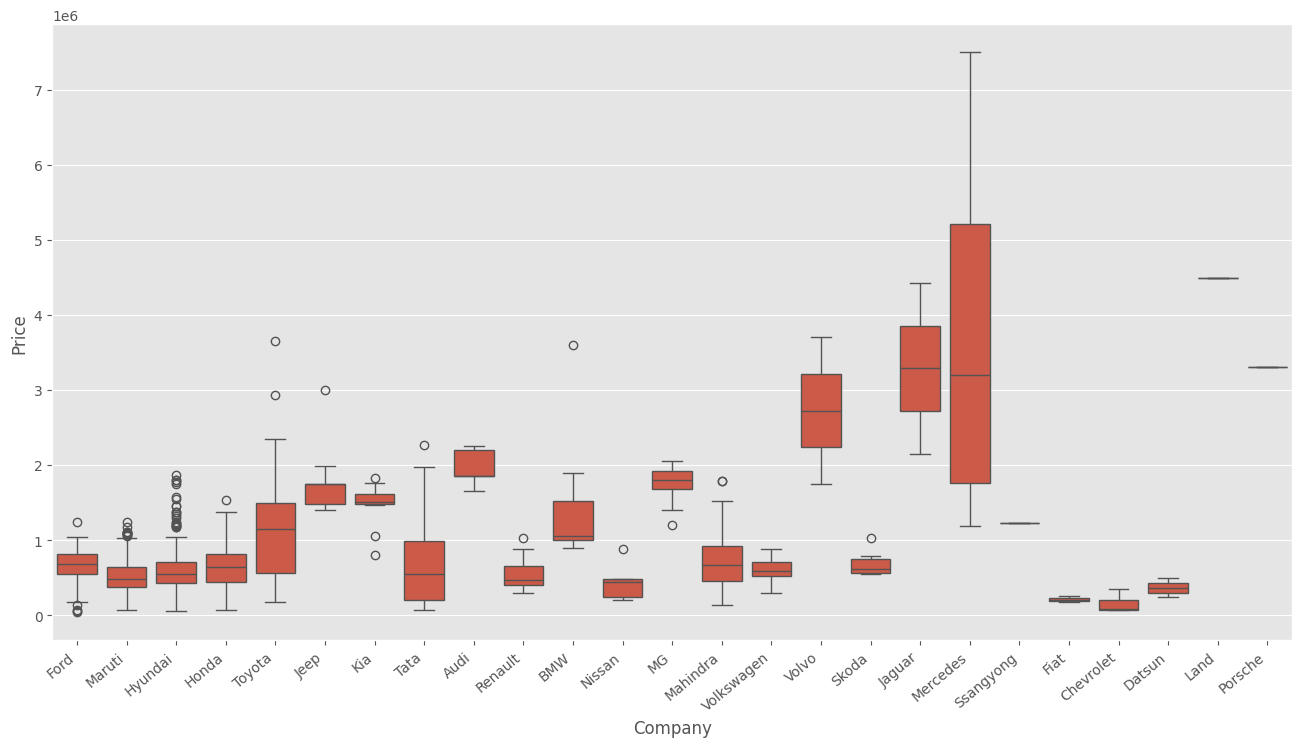

In [138]:
import seaborn as sns
plt.subplots(figsize=(16,8))
ax=sns.boxplot(x='Company',y='Price',data=car_data)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 15.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 13.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 6.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


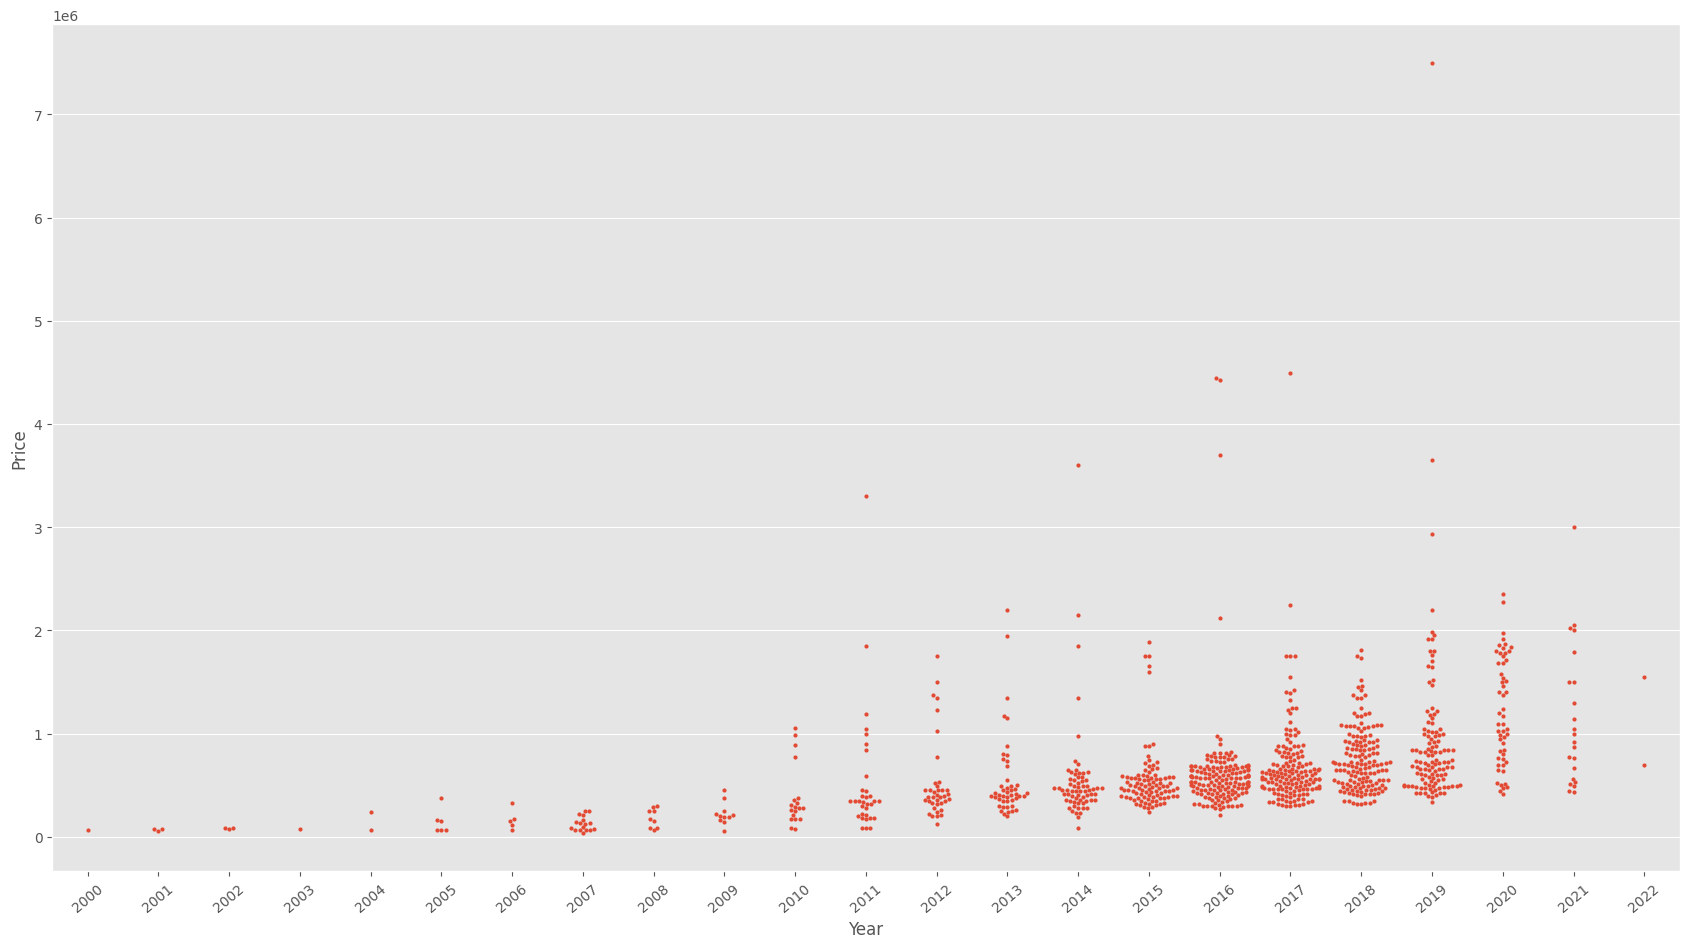

In [139]:
plt.subplots(figsize=(21, 11))
ax = sns.swarmplot(x='Year', y='Price', data=car_data, size=3)
ax.tick_params(axis='x', rotation=40)
plt.show()

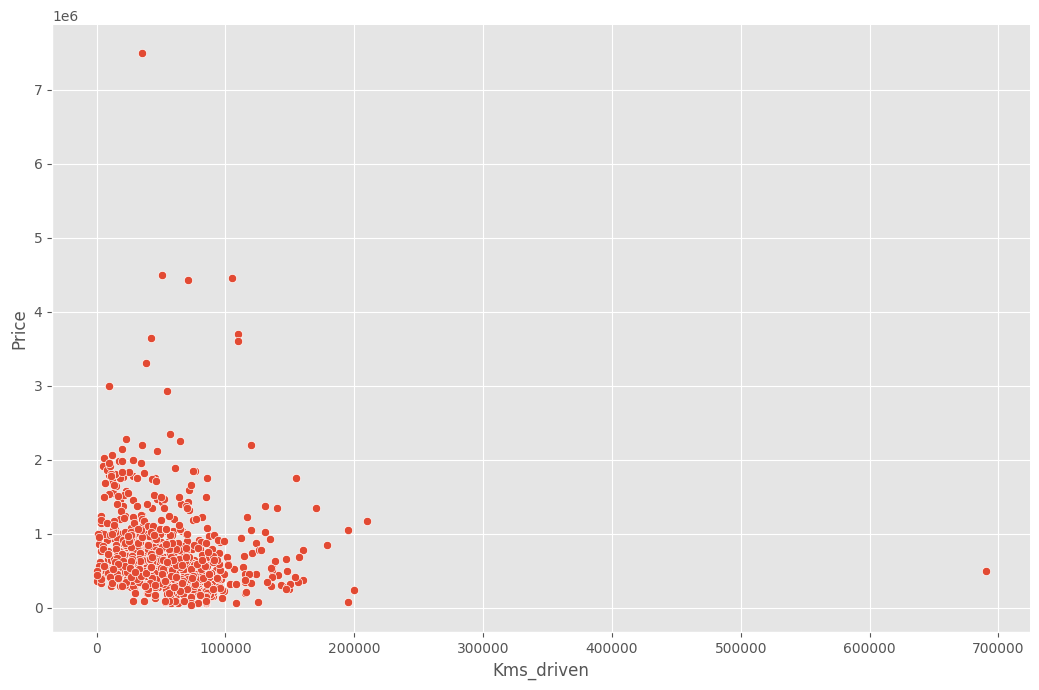

In [140]:
#checking relationship of kms with price
sns.relplot(x='Kms_driven',y='Price',data=car_data,height=7,aspect=1.5)

<Axes: xlabel='Fuel_type', ylabel='Price'>

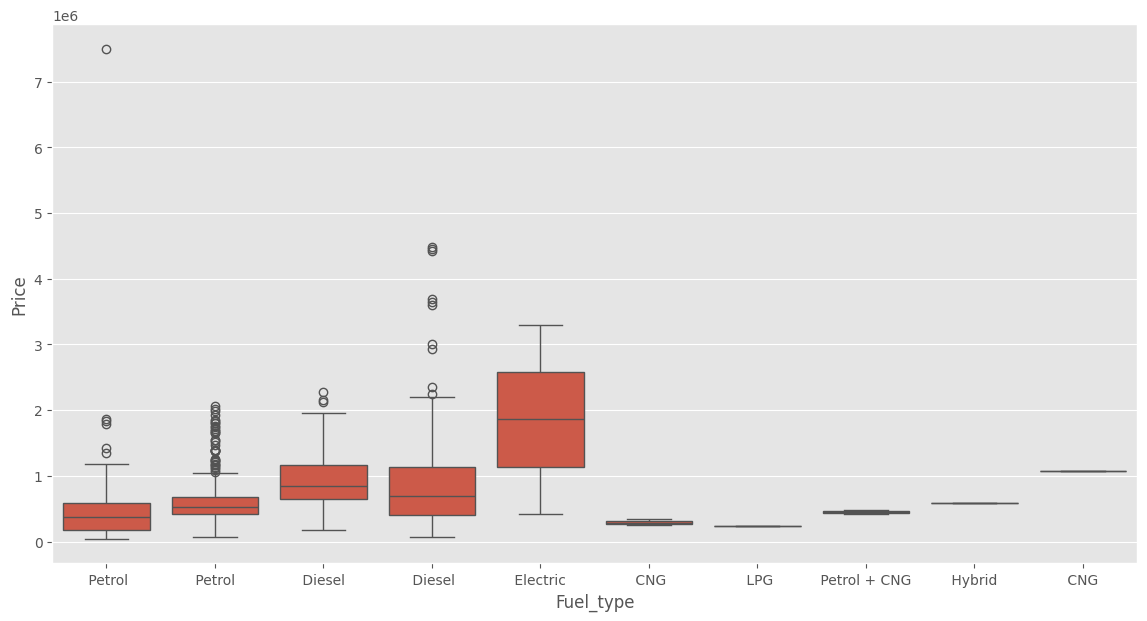

In [141]:
plt.subplots(figsize=(14,7))
sns.boxplot(x='Fuel_type',y='Price',data=car_data)

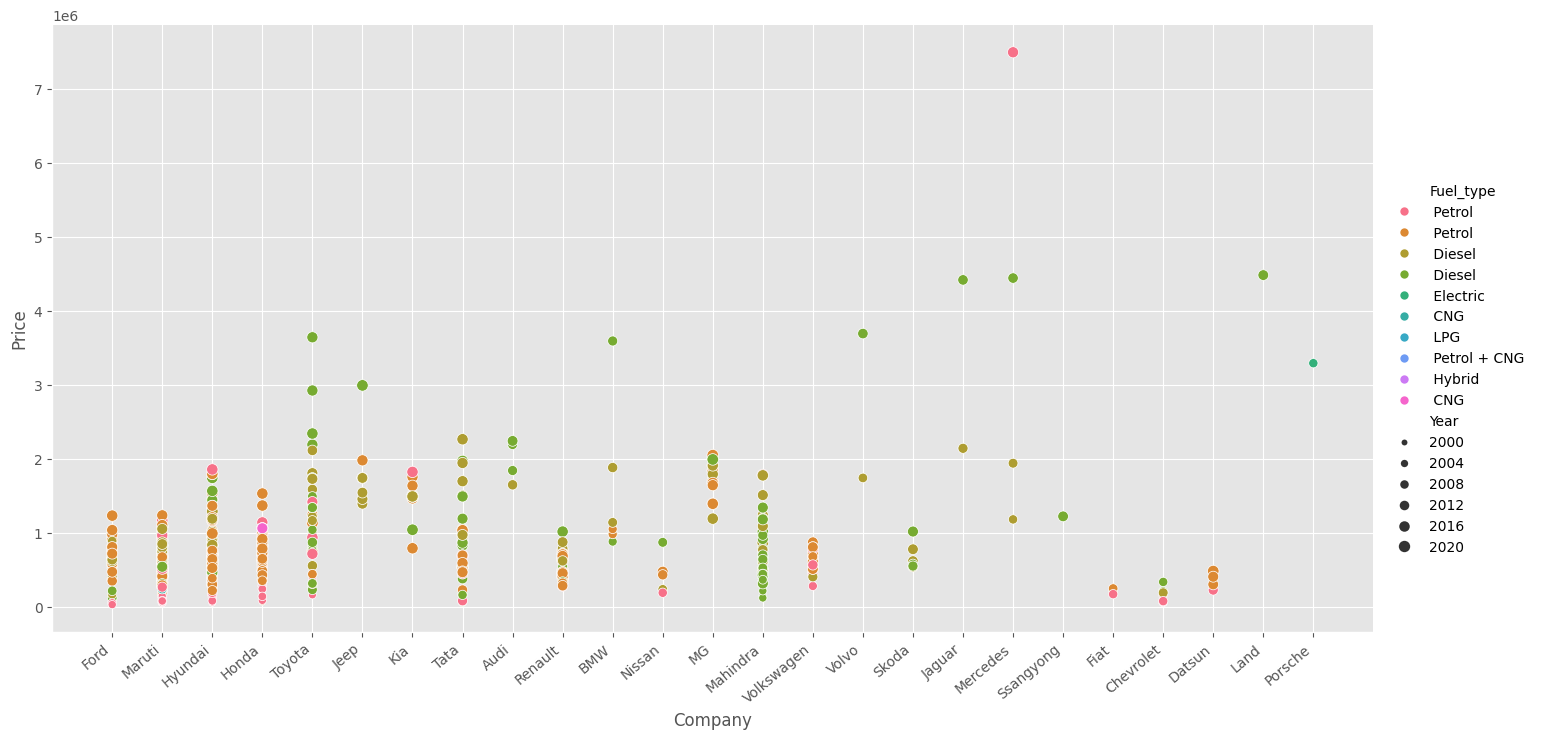

In [142]:
ax=sns.relplot(x='Company',y='Price',data=car_data,hue='Fuel_type',size='Year',height=7,aspect=2)
ax.set_xticklabels(rotation=40,ha='right')

In [89]:
X = car_data[['Name', 'Company', 'Year', 'Kms_driven', 'Fuel_type']]
y = car_data['Price']

In [143]:
X

,Name,Company,Year,Kms_driven,Fuel_type
0,Ford Figo Duratec,Ford,2015,35056,Petrol
1,Maruti Suzuki Wagon,Maruti,2016,44000,Petrol
2,Hyundai Creta 1.6,Hyundai,2018,42917,Petrol
3,Hyundai Venue -,Hyundai,2019,16112,Petrol
4,Honda Jazz -,Honda,2017,30988,Petrol
...,...,...,...,...,...
1021,Hyundai i10 Magna,Hyundai,2014,65000,Petrol
1022,Maruti Suzuki Alto,Maruti,2014,60000,Petrol
1023,Jeep Compass Limited,Jeep,2017,31000,Diesel
1024,Jeep Compass Limited,Jeep,2017,31000,Diesel


In [94]:
y.shape

(1026,)

In [97]:
# 1. Imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

# 2. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


ohe = OneHotEncoder()
ohe.fit(X[['Name', 'Company', 'Fuel_type']])

column_trans = make_column_transformer(
    (OneHotEncoder(categories=ohe.categories_), ['Name', 'Company', 'Fuel_type']),
    remainder='passthrough'
)

In [98]:
lr=LinearRegression()


In [117]:
pipe=make_pipeline(column_trans,lr)

In [144]:
pipe.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['Audi Q3 -', 'Audi Q5 2.0', 'Audi Q7 3.0', 'Audi Q7 35',
       'BMW 3 Series', 'BMW 5 Series', 'BMW X5 xDrive30d',
       'Chevrolet Aveo -', 'Chevrolet Beat -', 'Chevrolet Beat LS',
       'Chevrolet Beat LT', 'Chevrolet Cruze LTZ', 'Chevrolet Optra -',
       'Chevrolet S...
       'Hyundai', 'Jaguar', 'Jeep', 'Kia', 'Land', 'MG', 'Mahindra',
       'Maruti', 'Mercedes', 'Nissan', 'Porsche', 'Renault', 'Skoda',
       'Ssangyong', 'Tata', 'Toyota', 'Volkswagen', 'Volvo'], dtype=object),
                                                                            array([' CNG', ' CNG ', ' Diesel', ' Diesel ', ' Electric ', ' Hybrid ',
       ' LPG', ' Petrol', ' Petrol ', ' Petrol + CNG '], dtype=object)]),
                                                  ['Name', 'Company',
                                                   'Fuel_type'])])),
                ('linearregression', LinearRegression())])

In [104]:
y_pred=pipe.predict(X_test)

In [106]:
r2_score(y_test,y_pred)

0.4611324674096431

In [110]:
import numpy as np
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score


scores = []
for i in range(1000):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=i)
    lr = LinearRegression()
    pipe = make_pipeline(column_trans, lr)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    scores.append(r2_score(y_test, y_pred))

#Absolute best random state index
best_random_state = np.argmax(scores)
print(f"Best Random State Found: {best_random_state}")
print(f"Highest R2 Score achieved during loop: {scores[best_random_state]}")



Best Random State Found: 661
Highest R2 Score achieved during loop: 0.8277530830036166


In [122]:
pipe.predict(pd.DataFrame(columns=X_test.columns, data=np.array(['Maruti Suzuki Wagon', 'Maruti', 2019, 100, ' Petrol ']).reshape(1, 5)))



array([611317.47538291])

In [123]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=np.argmax(scores))
lr=LinearRegression()
pipe=make_pipeline(column_trans,lr)
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
r2_score(y_test,y_pred)

0.8277530830036166

In [124]:
import pickle
pickle.dump(pipe,open('LinearRegressionModel.pkl','wb'))

In [129]:
pipe.predict(pd.DataFrame(
    columns=['Name', 'Company', 'Year', 'Kms_driven', 'Fuel_type'],
    data=np.array(['Maruti Suzuki Wagon', 'Maruti', 2019, 100, ' Petrol ']).reshape(1, 5)
))



array([611317.47538291])

In [145]:
pipe.steps[0][1].transformers[0][1].categories[0]

array(['Audi Q3 -', 'Audi Q5 2.0', 'Audi Q7 3.0', 'Audi Q7 35',
       'BMW 3 Series', 'BMW 5 Series', 'BMW X5 xDrive30d',
       'Chevrolet Aveo -', 'Chevrolet Beat -', 'Chevrolet Beat LS',
       'Chevrolet Beat LT', 'Chevrolet Cruze LTZ', 'Chevrolet Optra -',
       'Chevrolet Sail 1.2', 'Chevrolet Spark -', 'Datsun GO T',
       'Datsun Redi GO', 'Fiat Linea Dynamic', 'Fiat Linea Emotion',
       'Fiat Punto Emotion', 'Ford EcoSport -', 'Ford EcoSport Ambiente',
       'Ford EcoSport Titanium', 'Ford EcoSport Trend', 'Ford Ecosport -',
       'Ford Ecosport 1.0', 'Ford Endeavor 4X4', 'Ford Figo -',
       'Ford Figo 1.5', 'Ford Figo Aspire', 'Ford Figo Diesel',
       'Ford Figo Duratec', 'Ford Freestyle -', 'Ford Freestyle TITANIUM',
       'Ford Ikon -', 'Honda Accord 2.4', 'Honda Amaze -',
       'Honda Amaze 1.2', 'Honda Amaze 1.5', 'Honda BRV -',
       'Honda Brio -', 'Honda Brio S', 'Honda CRV -', 'Honda City -',
       'Honda City 1.5', 'Honda City SV', 'Honda City V', 'Hon